# Infer a Kd from flow data for individual clones (not libraries)

This notebook requires two input files (and the flow cytometry data):
- a run-list which specifies the antibody and antigen that are being tested, along with the flow cytometry data directory
- a concentrations list which specifies the concentrations used (in -log10(Molar)), along with 'well' assignments for looking up the flow cytometry data (we use a 96-well format for making these measurements, so the well numbers are automatically output when we export the flow cytometry fcs files to csvs)

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
import collections
import glob
import scipy.optimize
import scipy.stats

In [17]:
#get run list
run_list = pd.read_csv('run-list.csv')
run_list = run_list.dropna(axis=0, how='any')  # drop columns with any NaN values
run_list['replicate'] = run_list['replicate'].astype(int)
run_list.head()

,directory,row,shortname,antigen,replicate
0,flow_data/omi32-germline_ba1_r1,E,Omi32,BA1,1
1,flow_data/omi32-germline_ba1_r2,E,Omi32,BA1,2
2,flow_data/omi32-germline_ba1_r1,A,Germline,BA1,1
3,flow_data/omi32-germline_ba1_r2,A,Germline,BA1,2


In [18]:
#get antigen concentrations
concentrations_list = pd.read_csv('concentrations-list.csv', index_col=[0])
cols = concentrations_list.index
concentrations_list

,BA1
well column,
1,6.0
2,7.0
3,8.0
4,9.0
5,10.0
6,10.5
7,14.0


In [19]:
# define functions for assigning csv to each mutant
def get_files(run_id):
    run_row = run_list.loc[run_id, :]
    wells = ['%c%02d' % (run_row['row'], i) for i in range(1, len(concentrations_list)+1)]

    def get_filename(well):
        search = os.path.join(run_row['directory'], f'*{well}*')
        filenames = glob.glob(search)
        if len(filenames) != 1:
            print(search, filenames)
            raise Exception(well)
        return filenames[0]

    return [pd.read_csv(get_filename(well)) for well in wells]


# #pin raw values (not log-transformed yet) to a safe detection threshold within linear detector range (based on average CST settings provided by UCSF Flow Core)
PIN_FLOOR = 100.0  # raw fluorescence floor; log10 floor = 2

def pin_fluor(run_id, floor=PIN_FLOOR, col='585/15 YG E-A'):
    run = get_files(run_id)

    for df in run:
        pe = df[col].astype(float).to_numpy()
        pe_pinned = np.maximum(pe, floor)
        df['PE_pinned'] = pe_pinned
        df['log_PE'] = np.log10(pe_pinned)

    run_row = run_list.loc[run_id, :]
    # optional: report how many values were pinned
    n_total = sum(len(df) for df in run)
    n_pinned = sum((df['PE_pinned'] == floor).sum() for df in run)
    print(run_row['shortname'], run_row['antigen'], f"pinned {n_pinned}/{n_total} < {floor}", sep='\t')

    return run


print('name', 'antigen', 'pin_stats', sep='\t')
runs = [pin_fluor(run_id) for run_id in run_list.index]
print(runs)


name	antigen	pin_stats
Omi32	BA1	pinned 10040/64921 < 100.0
Omi32	BA1	pinned 9854/69828 < 100.0
Germline	BA1	pinned 19025/75612 < 100.0
Germline	BA1	pinned 15556/69935 < 100.0
[[              FSC-A     FSC-H          FSC-W          SSC-A     SSC-H  \
0      80469.507812   50611.0  104199.679688   83114.171875   69659.0   
1      78622.218750   46738.0  110244.031250   56401.269531   47854.0   
2     101569.085938   67310.0   98892.179688   72372.734375   59267.0   
3     127345.007812   84573.0   98680.218750   61740.500000   53214.0   
4     186845.906250  133779.0   91532.554688   75815.859375   64971.0   
...             ...       ...            ...            ...       ...   
9950  108631.382812   66615.0  106871.820312   76278.164062   57279.0   
9951  170777.265625  106859.0  104736.695312  183131.109375  103190.0   
9952  168913.453125   96407.0  114824.765625  131908.937500   94115.0   
9953   71375.835938   41141.0  113698.906250  116279.843750   98081.0   
9954   76348.359375

## Fit fluorescence vs. [antigen] to get Kd

In [20]:
#https://elifesciences.org/articles/23156#s4

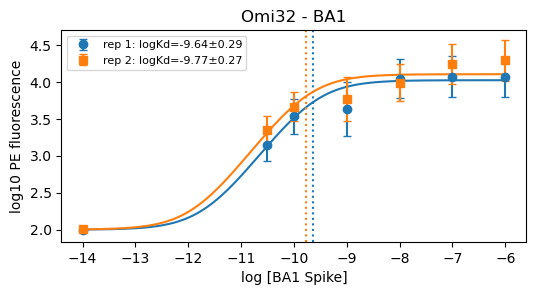

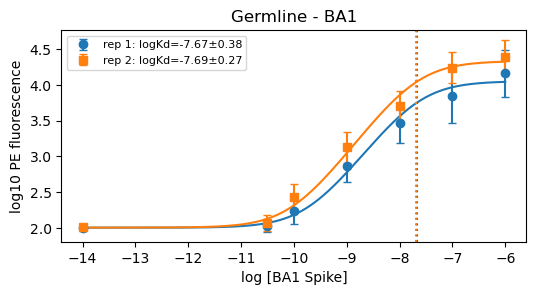

Done. Wrote KD/KD_err back into run_list and saved one PDF per shortname.


In [21]:
def sigmoid(c, Kd, A, B):
    return np.log10(A * (10**np.float64(c) / ((10**np.float64(c)) + (10**np.float64(Kd)))) + B)

def rms(y, yfit):
    return np.sqrt(np.sum((y - yfit)**2))

# init output columns
n_runs = run_list.shape[0]
run_list['KD'] = np.zeros(n_runs)
run_list['KD_err'] = np.zeros(n_runs)

# map run_id -> run data (1 dataframe per concentration)
run_by_id = {run_id: runs[i] for i, run_id in enumerate(run_list.index)}

# replicate styling (extend if you have >2 reps)
rep_colors = {
    1: "#1f77b4",
    2: "#ff7f0e",
    3: "#2ca02c",
    4: "#d62728",
    5: "#9467bd",
}
rep_markers = {1: "o", 2: "s", 3: "^", 4: "D", 5: "v"}

# plot one figure per set of antibody replicates (by shortname), overlay replicates
for shortname, grp in run_list.groupby('shortname', sort=False):

    # if a shortname spans multiple antigens, split further
    for antigen, grp2 in grp.groupby('antigen', sort=False):

        plt.figure(figsize=(6, 2.75))

        # concentrations for this antigen
        concs = (-concentrations_list[antigen]).copy()
        concs_plot = np.linspace(concs.min(), concs.max(), 300)

        # fit + plot each replicate
        for _, row in grp2.sort_values('replicate').iterrows():
            run_id = row.name  # index of run_list
            run = run_by_id[run_id]
            rep = int(row['replicate'])

            mean_log_fluor = [df['log_PE'].mean() for df in run]
            std_log_fluor  = [df['log_PE'].std()  for df in run]

            # curve_fit settings
            popt, pcov = scipy.optimize.curve_fit(
                sigmoid,
                concs,
                mean_log_fluor,
                p0=[(-9), 10**4, 10**2],
                sigma=std_log_fluor,
                absolute_sigma=True,
                bounds=[((-14), 1, 1), ((-5), 10**5, 10**5)],
                maxfev=400000
            )

            logKd = popt[0]
            logKd_err = float(np.sqrt(pcov[0][0])) if pcov.shape == (3,3) else np.nan

            # store results back into run_list row
            run_list.loc[run_id, 'KD'] = logKd
            run_list.loc[run_id, 'KD_err'] = logKd_err

            color = rep_colors.get(rep, "black")
            marker = rep_markers.get(rep, "o")

            plt.errorbar(
                concs, mean_log_fluor, yerr=std_log_fluor,
                fmt=marker, capsize=3, color=color,
                label=f"rep {rep}: logKd={logKd:.2f}±{logKd_err:.2f}"
            )
            plt.plot(concs_plot, sigmoid(concs_plot, *popt), color=color)
            plt.axvline(logKd, linestyle=":", color=color)

        plt.xlabel(f'log [{antigen} Spike]')
        plt.ylabel('log10 PE fluorescence')
        plt.legend(fontsize=8, loc='upper left')
        plt.title(f'{shortname} - {antigen}')
        plt.grid(False)

        # save per shortname+antigen
        outname = f"{shortname}_{antigen}_replicates.pdf"
        outname_png = f"{shortname}_{antigen}_replicates.png"
        #plt.savefig(f'images/{outname}', format="pdf", bbox_inches="tight")
        plt.savefig(f'images/{outname_png}', format="png", bbox_inches="tight", dpi=150)
        plt.show()

print("Done. Wrote KD/KD_err back into run_list and saved one PDF per shortname.")
